In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


In [2]:
#step 2: Data Load
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\mlops\Dataset\student-por.csv")

In [3]:
#step 3: Display Dataset Information
print("First Five Rows")
print(df.head())

First Five Rows
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]


In [4]:
print("\nShape of Dataset")
print(df.shape)


Shape of Dataset
(649, 33)


In [5]:
print("\nColumn Names")
print(df.columns.tolist())


Column Names
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [6]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [7]:
print(df.shape)

(649, 33)


In [8]:
#to fill null values by finding mean if null values there
df["age"]=df["age"].fillna(df["age"].mean())

In [9]:
# step4: define features and target
target="G3"

x=df.drop(columns=[target])
y=df[target]

In [10]:
# step5: identify numerical and categorical columns
from pandas.core.arrays import categorical
numerical_columns=x.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns=x.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)


Numerical Columns
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Categorical Columns
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


C:\Users\HP\AppData\Local\Temp\ipykernel_10896\1170653181.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns=x.select_dtypes(include=["object"]).columns.tolist()


In [11]:
# Step 6 : Numerical Pipeline

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [12]:
# Step 7 : Categorical Pipeline

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [13]:
# Step 8 : Combine Pipelines

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [14]:
# Step 9 : Split Dataset

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [15]:
# Step 10 : Fit Preprocessor on Training Data

preprocessor.fit(x_train)

# Transform Training and Testing Data

x_train_processed = preprocessor.transform(x_train)
x_test_processed = preprocessor.transform(x_test)

print("\nTraining Data Shape")
print(x_train_processed.shape)

print("\nTesting Data Shape")
print(x_test_processed.shape)


Training Data Shape
(519, 58)

Testing Data Shape
(130, 58)


In [16]:
# Step 11 : Transform Entire Dataset (without refitting)

processed_data = preprocessor.transform(x)

# Convert Sparse Matrix to DataFrame

if hasattr(processed_data, "toarray"):
    processed_data = processed_data.toarray()

processed_df = pd.DataFrame(processed_data)

# Add Target Column

processed_df["G3"] = y.values

# Save Processed Dataset

processed_df.to_csv(r"C:\Users\HP\OneDrive\Desktop\mlops\Dataset\processed_student-por.csv", index=False)

print("\nProcessed dataset saved successfully.")
print("File Name : processed_student-por.csv")

print("\nProcessed Dataset Shape")
print(processed_df.shape)


Processed dataset saved successfully.
File Name : processed_student-por.csv

Processed Dataset Shape
(649, 59)


exp 3

In [17]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [18]:
# Step 2 : Load Dataset
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\mlops\Dataset\student-por.csv")

In [19]:
# Step 3 : Feature Engineering
df["Average_Grade"]=(df["G1"]+df["G2"]) / 2
df["Study_Efficiency"]=df["studytime"]/(df["absences"]+1)
df["Parent_Education"]=(df["Medu"]+df["Fedu"])/2
df["Student_Wellbeing"]=(
  df["famrel"]+
  df["freetime"]+
  df["health"]
)/3


In [20]:
#Step 4 - Save Feature Store

feature_store = df[
    [
        "Average_Grade",
        "Study_Efficiency",
        "Parent_Education",
        "Student_Wellbeing"
    ]
]

feature_store.to_csv(
    r"C:\Users\HP\OneDrive\Desktop\mlops\Dataset\engineered_features.csv",
    index=False
)

print("\nFeature Store saved successfully.")



Feature Store saved successfully.


In [21]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Average_Grade', 'Study_Efficiency', 'Parent_Education', 'Student_Wellbeing']


In [22]:
#Step 5: Define target
target = "G3"
#original Dataset
X_original = df.drop(
    columns=[
        "G3",
        "Average_Grade",
        "Study_Efficiency",
        "Parent_Education",
        "Student_Wellbeing"
    ]
)
# Engineered Dataset
X_engineered = df[
    [
        "Average_Grade",
        "Study_Efficiency",
        "Parent_Education",
        "Student_Wellbeing"
    ]
]

In [23]:
# Function to train and evaluate model
def train_model(x,y):
  numerical_columns=x.select_dtypes(
    include=["int64","float64"]
  ).columns
  categorical_columns=x.select_dtypes(
    include=["object"]
  ).columns
  preprocessor=ColumnTransformer(
    [
      (
        "num",
        Pipeline([
          ("imputer",SimpleImputer(strategy="mean"))
        ]),
        numerical_columns
      ),
      (
        "cat",
        Pipeline([
          ("imputer",SimpleImputer(strategy="most_frequent")),
          ("encoder",OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_columns
        )
    ]
  )
  x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
  )
  x_train=preprocessor.fit_transform(x_train)
  x_test=preprocessor.transform(x_test)
  model=RandomForestRegressor(n_estimators=100,random_state=42)
  model.fit(x_train,y_train)
  predictions=model.predict(x_test)
  score=r2_score(y_test,predictions)
  return score

In [24]:
score_original = train_model(
    X_original,
    y
)

score_engineered = train_model(
    X_engineered,
    y
)

print(
    "\nR² Score Without Feature Engineering :",
    round(score_original, 3)
)

print(
    "R² Score With Feature Engineering :",
    round(score_engineered, 3)
)

C:\Users\HP\AppData\Local\Temp\ipykernel_10896\1376910584.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns=x.select_dtypes(



R² Score Without Feature Engineering : 0.839
R² Score With Feature Engineering : 0.726


In [25]:
stored_features = pd.read_csv(
    r"C:\Users\HP\OneDrive\Desktop\mlops\Dataset\engineered_features.csv"
)

print("\nStored Features")

print(stored_features.head())


Stored Features
   Average_Grade  Study_Efficiency  Parent_Education  Student_Wellbeing
0            5.5          0.400000               4.0           3.333333
1           10.0          0.666667               1.0           3.666667
2           12.5          0.285714               1.0           3.333333
3           14.0          3.000000               3.0           3.333333
4           12.0          2.000000               3.0           4.000000


EXP 4

In [26]:
import os
import joblib   
import pandas as pd

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error



In [27]:
# create model folder

os.makedirs("models", exist_ok=True)

In [28]:
# load processed dataset

df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\mlops\Dataset\processed_student-por.csv")

In [29]:
# define target

target = "G3"
X = df.drop(columns=[target])
y = df[target]

In [30]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [31]:
lr=LinearRegression()
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)
lr_r2=r2_score(y_test,lr_pred)
lr_mae=mean_absolute_error(y_test,lr_pred)

In [32]:
#save model

joblib.dump(lr, "models/linear_regression_model.pkl")

['models/linear_regression_model.pkl']

In [33]:
#model 2
#random forest

rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
rf_r2=r2_score(y_test,rf_pred)
rf_mae=mean_absolute_error(y_test,rf_pred)

In [34]:
#save model

joblib.dump(rf, "models/random_forest.pkl")

['models/random_forest.pkl']

In [ ]:
registry=pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Version": ["1.0", "1.0"],
    "R2 Score": [lr_r2, rf_r2],
    "MAE": [lr_mae, rf_mae],
    "Date": [datetime.now(), datetime.now()]
})
best_model=registry.loc[registry["R2 Score"].idxmax(), "Model"]
registry["Status"] = registry["Model"].apply(lambda x: "Production" if x == best_model else "Staging")
registry.to_csv("models/model_registry.csv", index=False)

In [36]:

if best_model=="Random Forest":
    model=joblib.load("models/random_forest_model.pkl")
else:
    model=joblib.load("models/linear_regression_model.pkl")

In [37]:
predictions = model.predict(X_test.iloc[[0]])

print("\nPredictions for the First Test Student")
print(round(predictions[0], 2))
print("\nActual G3")
print(y_test.iloc[0])
print("\nBest_model")
print(best_model)
print("\nModel Registry Created Successfully")


Predictions for the First Test Student
18.4

Actual G3
19

Best_model
Linear Regression

Model Registry Created Successfully


EXP 5

In [38]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


In [39]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\mlops\Dataset\processed_student-por.csv")
target="G3"
X=df.drop(columns=[target])
y=df[target]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
baseline_model = RandomForestRegressor(random_state=42)
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)
baseline_score = r2_score(y_test, baseline_predictions)
print("\nBaseline R² Score:", round(baseline_score, 3))


Baseline R² Score: 0.839


In [42]:
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth":[5,10,None],
    "min_samples_split":[2,5,10],
}

In [43]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("\nBest Parameters")
print(grid_search.best_params_)


Best Parameters
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [44]:
best_model = grid_search.best_estimator_
prediction = best_model.predict(X_test)
tuned_score = r2_score(y_test, prediction)
print("\nTuned R² Score:", round(tuned_score, 3))


Tuned R² Score: 0.848


In [45]:
joblib.dump(best_model, "models/tuned_random_forest_.pkl")
print("\nTuned Model Saved Successfully")


Tuned Model Saved Successfully


In [46]:
comparison = pd.DataFrame({
    "Model":[
        "Baseline",
        "Tuned"
    ],
    "R² Score":[
        baseline_score,
        tuned_score
    ]
})
print("\nComparison Table")
print(comparison)


Comparison Table
      Model  R² Score
0  Baseline  0.839288
1     Tuned  0.848050


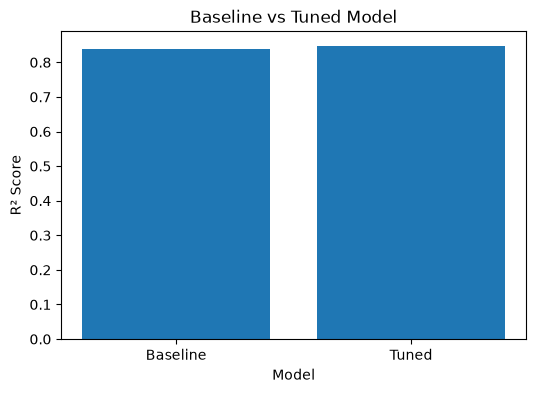

In [47]:
plt.figure(figsize=(6, 4))
plt.bar(comparison["Model"], comparison["R² Score"]
)
plt.title("Baseline vs Tuned Model")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.show()

EXP 6. model deplyment preparation

In [48]:
import os
import joblib
import pandas as pd
from datetime import datetime
from sklearn.metrics import r2_score

In [49]:
os.makedirs("deployment", exist_ok=True)

In [50]:
# load processed dataset
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\mlops\Dataset\processed_student-por.csv")
target = "G3"
X = df.drop(columns=[target])
y = df[target]

In [51]:
#load tuned model
tuned_model = joblib.load("models/tuned_random_forest_.pkl")
print("\nTuned Model Loaded Successfully")


Tuned Model Loaded Successfully


In [52]:
#test prediction
prediction = tuned_model.predict(X.iloc[[0]])
print("\nPrediction for the First Student")
print(round(prediction[0], 2))
print("\nActual G3")
print(y.iloc[0])


Prediction for the First Student
10.72

Actual G3
11


In [54]:
#evaluate model
predictions = tuned_model.predict(X)
score = r2_score(y, predictions)
print("\nOverall R2 Score")
print(round(score, 3))


Overall R2 Score
0.913


In [55]:
#save deployment model
joblib.dump(model,"deployment/deployment_model.pkl")
print("\nDeployment Model Saved Successfully")


Deployment Model Saved Successfully


In [ ]:
#create deployment information
with open("deployment/deployment_info.txt", "w") as file:
    file.write("MODEL DEPLOYMENT INFORMATION\n")
    file.write("Model Name: Tuned Random Forest\n")
    file.write("Algorithm: Random Forest Regressor\n")
    file.write("Version: 1.0\n")
    file.write("Dataset: student performance Dataset\n")
    file.write("Target: G3\n")
    file.write(f"R2 Score: {round(score, 3)}\n")
    file.write(f"Created On: {datetime.now()}\n")
print("Deployment Information File Created")

Deployment Information File Created
